# 01. 데이터 가져오기

In [1]:
import pandas as pd

file_path = '../../data/Imputation_Test.xlsx'
sheet_index = 0 
test_data = pd.read_excel(file_path, sheet_name=sheet_index)

---

# 02. 데이터 형태 정리 및 독립변수 분리

In [2]:
df = test_data.copy()
df = df.iloc[:, 3:]
df.columns = df.iloc[1]
df = df.drop([0, 1]).reset_index(drop=True)

data = df.iloc[:, :53] #독립변수만 분리

selected_cols = [
    'Index', 'Class1', 'Class2', 'CaO', 'Al2O3', 'SiO2', 'Fe2O3', 'SO3', 'MgO', 'etc',
    'FM', 'MeanV', 'Density', 'Blain', 'HG', 'AG', 'DG', 'Gyp_per', 'WC_per'
]
data = data[selected_cols]  # 필요한 컬럼 리스트 지정

cols_to_convert = data.columns[3:]  # Index, Class1, Class2 제외한 칼럼들을 수치형 컬럼으로 변환
data[cols_to_convert] = data[cols_to_convert].apply(pd.to_numeric, errors='coerce')

---

# 03. 1D-CNN을 활용한 결측치 대체

#### 01) 기준이 되는 mean 데이터 생성

In [5]:
mean = data.copy()
mean = mean.fillna(mean.mean(numeric_only=True))
mean

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.500000,7.394,3.100,6286.0,1.0,0.0,0.0,20.0,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.180000,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.312268,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,3.312268,8.221,2.941,6042.0,0.0,0.0,1.0,40.0,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,3.312268,7.526,3.000,5987.0,1.0,0.0,0.0,25.0,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.312268,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50


#### 02) 5회 반복

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# 설정
target_cols = ['FM', 'MeanV', 'Density', 'Blain', 'HG', 'AG', 'DG', 'Gyp_per', 'WC_per']
num_cols = mean.select_dtypes(include='float64').columns.tolist()
original_nan_idx = {col: data[data[col].isna()].index.tolist() for col in target_cols}
print(original_nan_idx)
n_iter = 5  # 반복 횟수

# PyTorch Dataset
class ImputationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]

# 1D-CNN 정의
class CNN1D(nn.Module):
    def __init__(self, input_length):
        super(CNN1D, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8 * input_length, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(1)

# 평균으로 채운 데이터 복사 (한 번만)
df_filled = mean.copy()

# 결과 저장용
results = {col: pd.DataFrame(index=original_nan_idx[col]) for col in target_cols}

{'FM': [441, 442, 443, 444, 445, 446, 447, 448, 449, 450], 'MeanV': [431, 432, 433, 434, 435, 436, 437, 438, 439, 440], 'Density': [421, 422, 423, 424, 425, 426, 427, 428, 429, 430], 'Blain': [411, 412, 413, 414, 415, 416, 417, 418, 419, 420], 'HG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410], 'AG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410], 'DG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410], 'Gyp_per': [391, 392, 393, 394, 395, 396, 397, 398, 399, 400], 'WC_per': [381, 382, 383, 384, 385, 386, 387, 388, 389, 390]}


In [7]:
# 🔁 연쇄적 반복 시작
for iter_idx in range(n_iter):
    print(f"\n================== Iteration {iter_idx+1} ==================")
    scaler = StandardScaler()

    for target in target_cols:
        print(f"\n Now imputing: {target}")

        # 원래 결측치 위치 복원
        df_filled.loc[original_nan_idx[target], target] = np.nan

        # 정규화
        df_scaled = df_filled.copy()
        df_scaled[num_cols] = df_scaled[num_cols].apply(pd.to_numeric, errors='coerce')
        scaler.fit(df_scaled[num_cols].dropna())
        df_scaled[num_cols] = scaler.transform(df_scaled[num_cols])

        input_cols = [col for col in num_cols if col != target]
        mask_train = df_scaled[target].notna()
        mask_test = df_scaled[target].isna()

        X_train = df_scaled.loc[mask_train, input_cols]
        y_train = df_scaled.loc[mask_train, target]
        X_test = df_scaled.loc[mask_test, input_cols]

        mask_valid = ~X_train.isna().any(axis=1)
        X_train = X_train[mask_valid]
        y_train = y_train[mask_valid]

        train_dataset = ImputationDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model = CNN1D(input_length=len(input_cols))
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        for epoch in range(100):
            model.train()
            for xb, yb in train_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                if torch.isnan(loss):
                    print(f"⚠️ NaN loss 발생: {target}")
                    break
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # 예측 및 누적 반영
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).unsqueeze(1)
            y_pred_scaled = model(X_test_tensor).numpy()

        # 🔁 스케일 복구 (inverse transform)
        target_idx = num_cols.index(target)
        target_mean = scaler.mean_[target_idx]
        target_scale = scaler.scale_[target_idx]
        y_pred = y_pred_scaled * target_scale + target_mean  # 복구된 원래 스케일 값

        # 예측 결과 저장 및 누적 반영
        results[target][f"iter{iter_idx+1}"] = pd.Series(y_pred, index=original_nan_idx[target])
        df_filled.loc[original_nan_idx[target], target] = y_pred  # ⬅️ 누적 대체 핵심

# 🔚 마지막 반복 결과 반영
result_df = df_filled.copy()


================== Iteration 1 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 2 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 3 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 4 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 5 

In [8]:
result_df

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.500000,7.394,3.100,6286.0,1.0,0.0,0.0,20.0,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.180000,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.091019,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,4.178270,8.221,2.941,6042.0,0.0,0.0,1.0,40.0,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,4.295064,7.526,3.000,5987.0,1.0,0.0,0.0,25.0,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.091019,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50


---

# 04. 최종 오차 예측

#### 01) label_data(정답 데이터) 저장

In [9]:
# label값이 저장되어있는 데이터 불러오기 (초기 코드는 동일)
file_path = '../../data/Imputation_Test.xlsx'
sheet_index = 1 
test_data = pd.read_excel(file_path, sheet_name=sheet_index)

df = test_data.copy()
df = df.iloc[:, 3:]
df.columns = df.iloc[1]
df = df.drop([0, 1]).reset_index(drop=True)

data = df.iloc[:, :53] #독립변수만 분리

selected_cols = [
    'Index', 'Class1', 'Class2', 'CaO', 'Al2O3', 'SiO2', 'Fe2O3', 'SO3', 'MgO', 'etc',
    'FM', 'MeanV', 'Density', 'Blain', 'HG', 'AG', 'DG', 'Gyp_per', 'WC_per'
]
data = data[selected_cols]  # 필요한 컬럼 리스트 지정

cols_to_convert = data.columns[3:]  # Index, Class1, Class2 제외한 칼럼들을 수치형 컬럼으로 변환
data[cols_to_convert] = data[cols_to_convert].apply(pd.to_numeric, errors='coerce')

label_data = data.copy()
label_data

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.50,7.394,3.100,6286.0,1,0,0,20,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.84,5.120,2.930,6152.0,1,0,0,25,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.84,5.120,2.930,6152.0,1,0,0,25,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.84,5.120,2.930,6152.0,1,0,0,25,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.18,5.450,2.910,5994.0,1,0,0,25,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.18,5.450,2.910,5994.0,1,0,0,25,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,4.20,8.221,2.941,6042.0,0,0,1,40,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,4.30,7.526,3.000,5987.0,1,0,0,25,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.18,5.450,2.910,5994.0,1,0,0,25,0.50


#### 02) 오차 ( |예측값-실제값| ) 확인

In [10]:
# 결과를 누적할 리스트
records = []

# 타겟 컬럼별로 결측치 인덱스에 대해 오차 기록
for col in target_cols:
    missing_idx = original_nan_idx[col]
    
    for idx in missing_idx:
        true_val = label_data.loc[idx, col]
        pred_val = result_df.loc[idx, col]
        error = abs(pred_val - true_val)
        
        records.append({
            'Column': col,
            'Index': idx,
            'True Value': true_val,
            'Predicted Value': pred_val,
            'Error': error
        })

error_df = pd.DataFrame(records)

In [14]:
error_df

,Column,Index,True Value,Predicted Value,Error
0,FM,441,3.36,2.282733,1.077267
1,FM,442,4.40,4.350948,0.049052
2,FM,443,3.18,3.062869,0.117131
3,FM,444,4.40,4.331784,0.068216
4,FM,445,2.84,2.812681,0.027319
...,...,...,...,...,...
85,WC_per,386,0.50,0.412863,0.087137
86,WC_per,387,0.40,0.414292,0.014292
87,WC_per,388,0.40,0.414292,0.014292
88,WC_per,389,0.40,0.414292,0.014292


In [15]:
# error_df.to_csv("cnn_5_error.csv", index=False, encoding='utf-8-sig')

In [12]:
# 오차값 반올림하여 확인
error_df_rounded = error_df.copy()
error_df_rounded["Error"] = error_df_rounded["Error"].round(6)
# error_df_rounded.to_csv("cnn_5_error_rounded.csv", index=False, encoding='utf-8-sig')
error_df_rounded

,Column,Index,True Value,Predicted Value,Error
0,FM,441,3.36,2.282733,1.077267
1,FM,442,4.40,4.350948,0.049052
2,FM,443,3.18,3.062869,0.117131
3,FM,444,4.40,4.331784,0.068216
4,FM,445,2.84,2.812681,0.027319
...,...,...,...,...,...
85,WC_per,386,0.50,0.412863,0.087137
86,WC_per,387,0.40,0.414292,0.014292
87,WC_per,388,0.40,0.414292,0.014292
88,WC_per,389,0.40,0.414292,0.014292


#### 03) 각 칼럼별 MAE, RMSE, R2 Score 확인

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 컬럼별 성능 요약 테이블
metrics = []

for col in target_cols:
    df_col = error_df[error_df['Column'] == col]

    y_true = df_col['True Value'].values
    y_pred = df_col['Predicted Value'].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    metrics.append({
        'Column': col,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

metrics_df = pd.DataFrame(metrics)
metrics_df

,Column,MAE,RMSE,R2 Score
0,FM,0.160387,0.346698,0.648952
1,MeanV,0.363353,0.920724,0.774086
2,Density,0.003584,0.005909,0.942850
3,Blain,30.044878,51.831950,0.649459
4,HG,0.215648,0.411992,-0.060857
5,AG,0.034928,0.041658,0.000000
6,DG,0.212205,0.433430,-0.174133
7,Gyp_per,3.381430,5.627587,0.709452
8,WC_per,0.041616,0.047503,-1.507308


# 05. 시각화

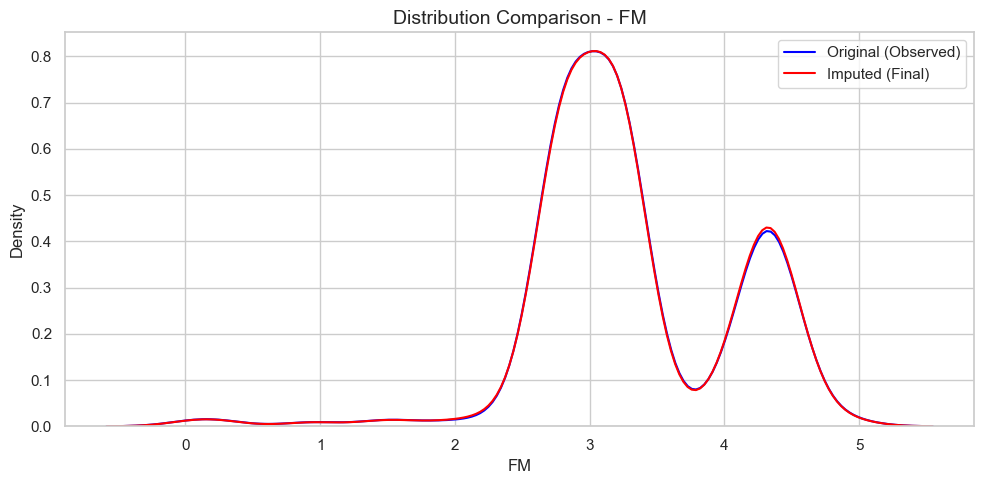

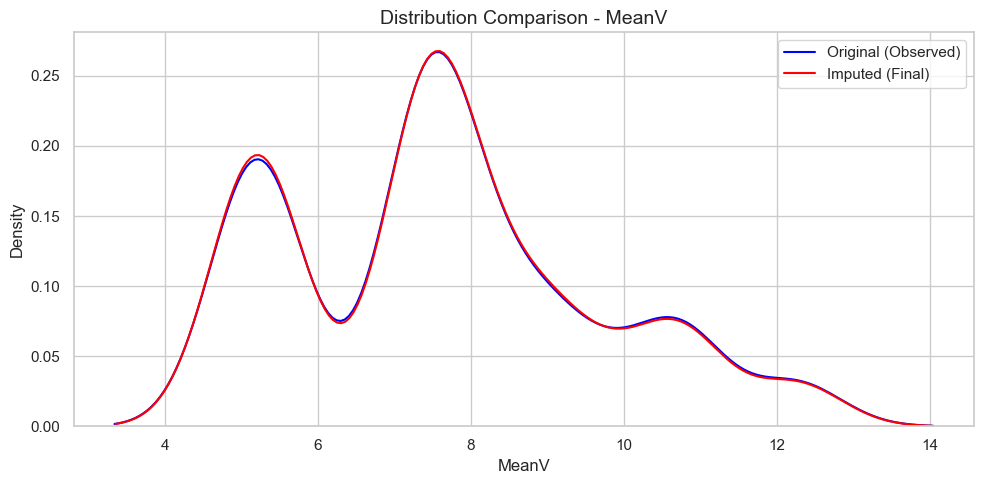

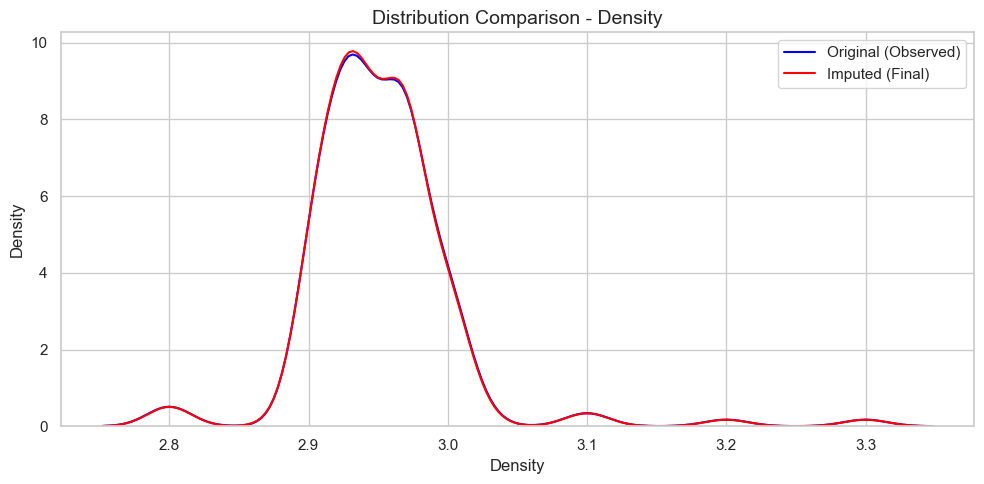

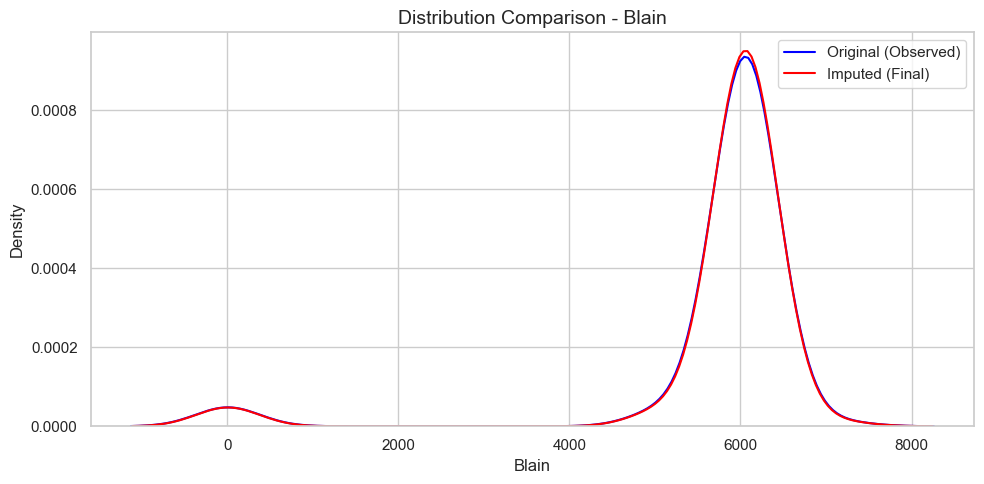

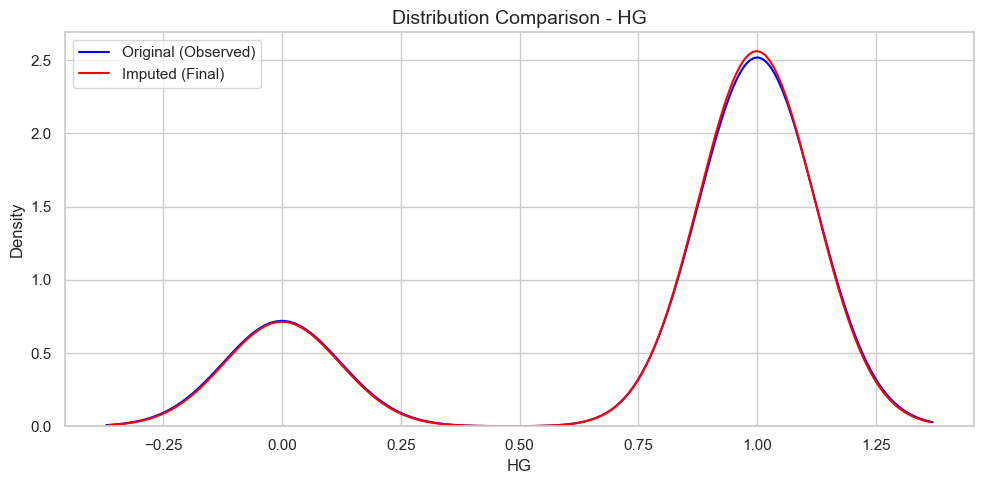

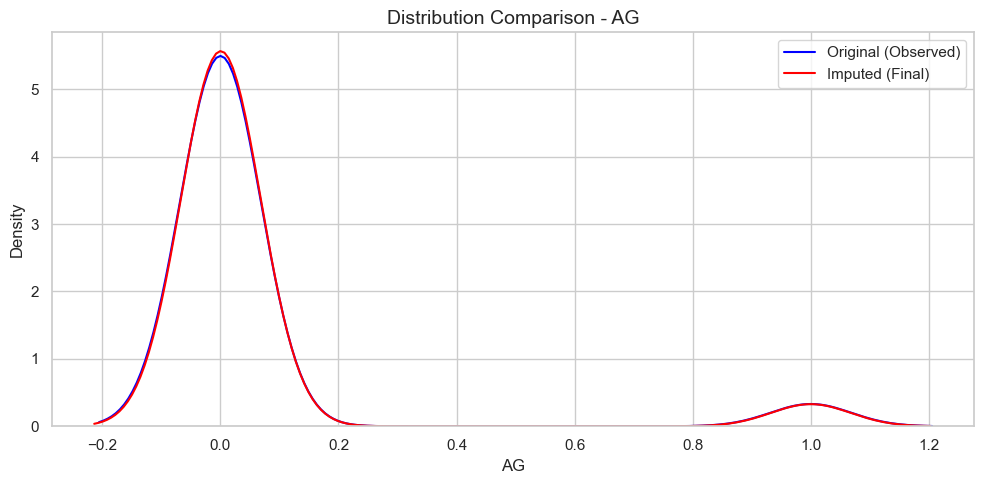

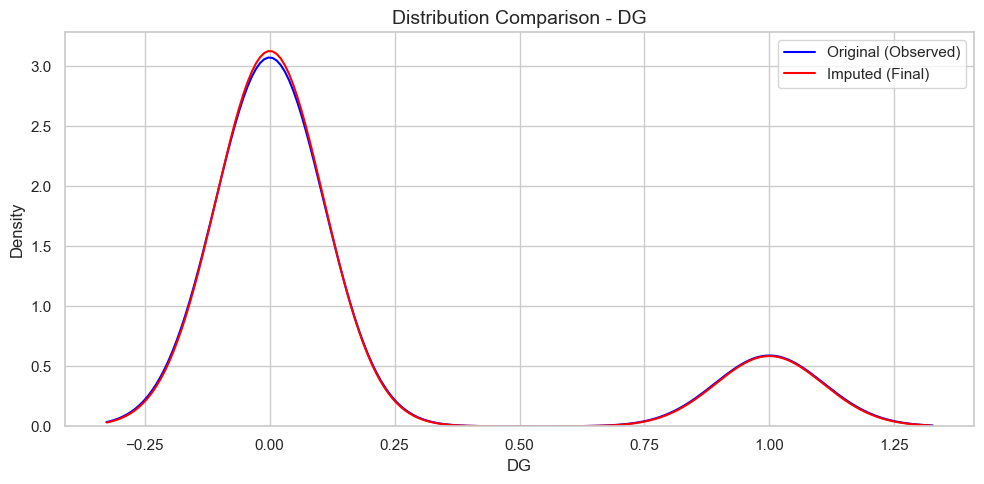

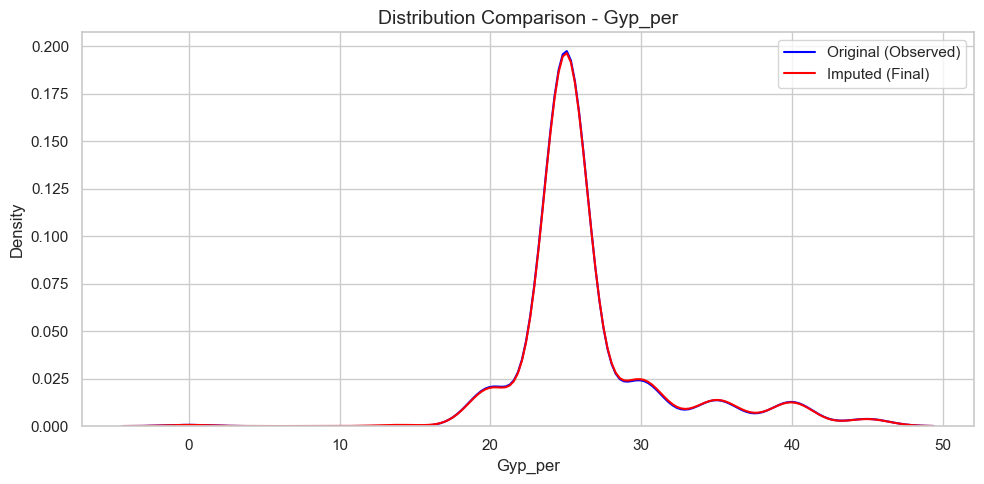

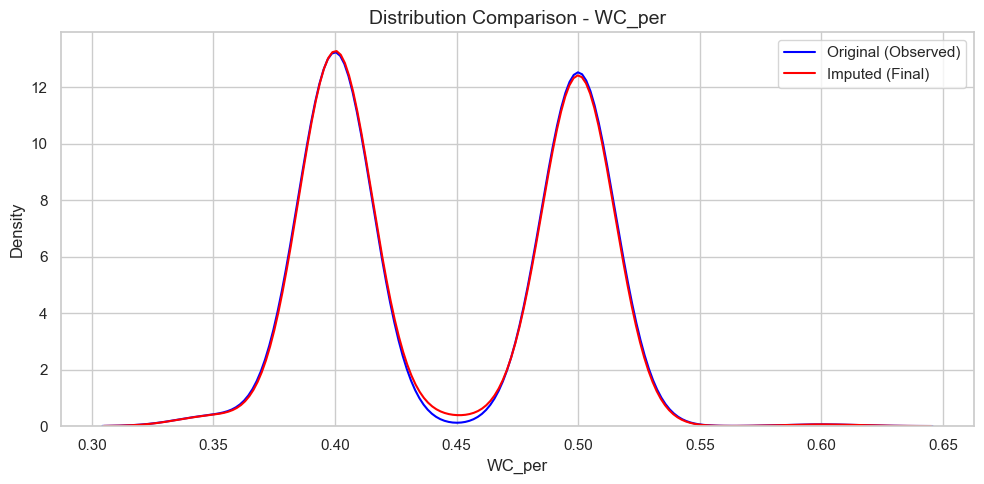

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 지정 (선택)
sns.set(style='whitegrid')

# 모든 타겟 컬럼에 대해 반복 시각화
for col in target_cols:
    plt.figure(figsize=(10, 5))
    
    # ① 결측치였던 값들 (예측값)
    imputed_idx = original_nan_idx[col]
    imputed_values = result_df.loc[imputed_idx, col]
    
    # ② 원래 결측치가 없던 값들
    observed_values = label_data.loc[:, col].dropna().drop(index=imputed_idx)

    # ③ 최종 전체 결과값 (결측치 대체 포함)
    final_values = result_df[col]

    # KDE or histogram
    sns.kdeplot(observed_values, label='Original (Observed)', color='blue')
    sns.kdeplot(final_values, label='Imputed (Final)', color='red')
    # sns.kdeplot(imputed_values, label='Predicted (Imputed)', color='green', linestyle='--')


    plt.title(f'Distribution Comparison - {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()